# Benchmark - Anthropic's Claude Opus 5

**Date:** 12-15 Aug 2026

**Evaluation:** Tasks 01-07

**Hardware:** Cloud

In [1]:
import textwrap

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.patches import Patch

from benchmark_lib import (
  DATA_DIR,
  RUNS_PER_BATCH,
  SERIES,
  add_token_counts,
  compare_skills,
  latest_batches,
  load_runs,
  metric_table,
  plot_benchmark,
  plot_skill_summary,
  save_runs,
)

HARDWARE = "cloud"
MODEL_LABEL = "Claude Opus 5"


In [2]:
MODEL_NAME = "claude-opus-5"
benchmark_dir = DATA_DIR / "anthropic" / "claude-opus-5"

if (not (benchmark_dir / "benchmark.csv").exists()):
  all_runs = load_runs(model=MODEL_NAME, hardware=HARDWARE)
  df = add_token_counts(latest_batches(all_runs))
  save_runs(df, benchmark_dir, redact=("anthropic",))


In [3]:
benchmark = pd.read_csv(benchmark_dir / "benchmark.csv")
benchmark["start_time"] = pd.to_datetime(benchmark["start_time"])
benchmark.head()


,task,run,start_time,skills,score,points,total,passed,structure_match,duration_seconds,...,model,harness,model_server,hardware,fields,input_tokens,output_tokens,cache_read_tokens,cache_write_tokens,total_tokens
0,01-data-loading,20260812_181745_1,2026-08-12 18:17:45.782456,False,1.0,5,5,True,True,83,...,claude-opus-5,pi,anthropic,cloud,"{'n_cells': {'expected': 20857, 'actual': 2085...",22,3601,52385,7622,63630
1,01-data-loading,20260812_181909_2,2026-08-12 18:19:09.765633,False,1.0,5,5,True,True,107,...,claude-opus-5,pi,anthropic,cloud,"{'n_cells': {'expected': 20857, 'actual': 2085...",20,5513,61546,8440,75519
2,01-data-loading,20260812_182057_3,2026-08-12 18:20:57.198450,False,1.0,5,5,True,True,89,...,claude-opus-5,pi,anthropic,cloud,"{'n_cells': {'expected': 20857, 'actual': 2085...",16,3456,36620,4991,45083
3,01-data-loading,20260812_182226_4,2026-08-12 18:22:26.465600,False,1.0,5,5,True,True,84,...,claude-opus-5,pi,anthropic,cloud,"{'n_cells': {'expected': 20857, 'actual': 2085...",18,3432,42311,5032,50793
4,01-data-loading,20260812_182350_5,2026-08-12 18:23:50.906132,False,1.0,5,5,True,True,81,...,claude-opus-5,pi,anthropic,cloud,"{'n_cells': {'expected': 20857, 'actual': 2085...",22,3145,53861,5301,62329


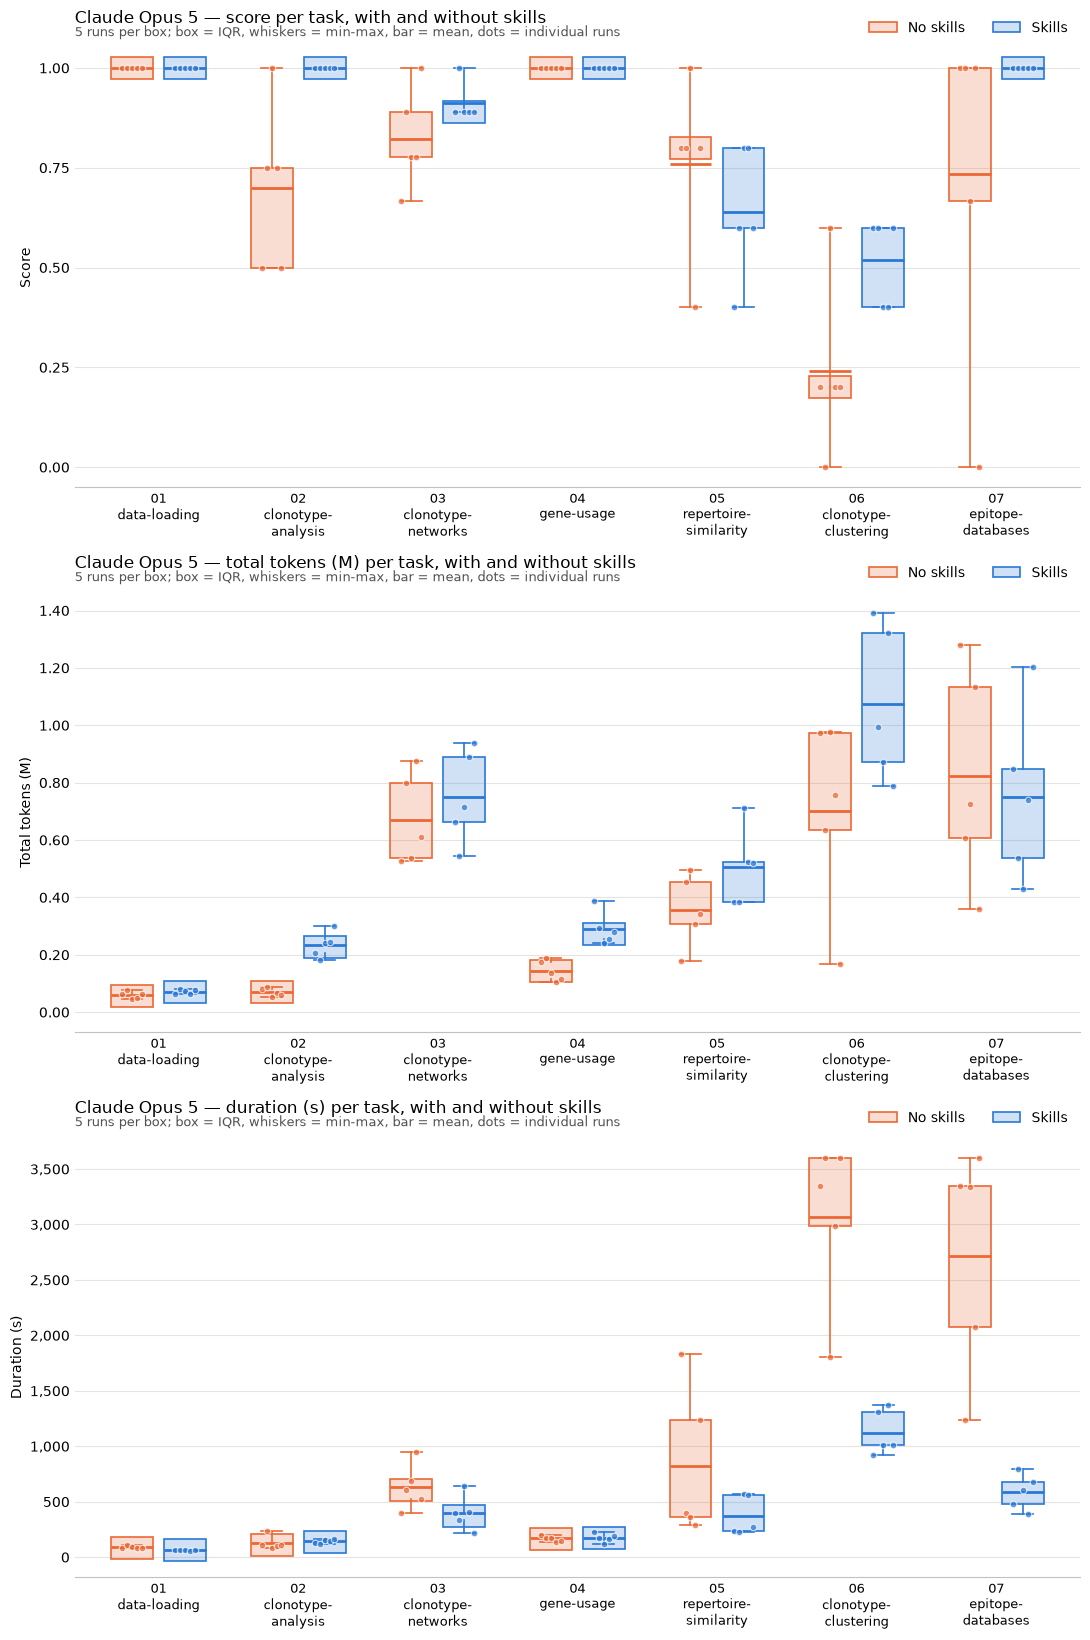

In [4]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(11, 5.5 * 3))
plot_benchmark(benchmark, column="score", model_label=MODEL_LABEL, ax=axs[0])
plot_benchmark(benchmark, column="total_tokens", model_label=MODEL_LABEL, ax=axs[1])
plot_benchmark(benchmark, column="duration_seconds", model_label=MODEL_LABEL, ax=axs[2])
fig.tight_layout()
plt.show()


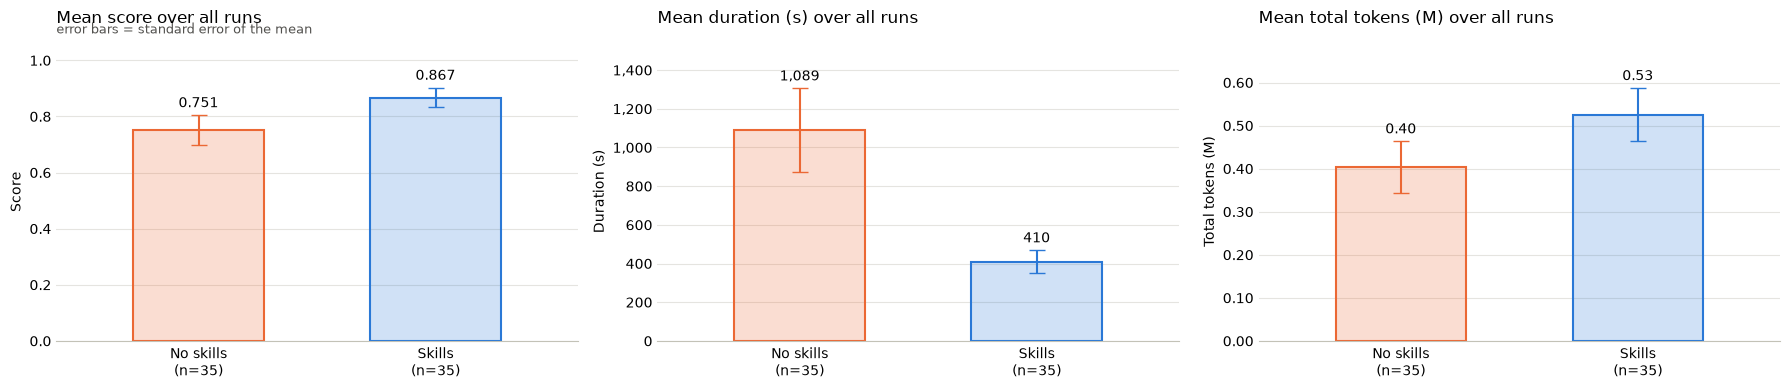

In [5]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(6 * 3, 4))
plot_skill_summary(benchmark, axs=axs)
fig.tight_layout()
plt.show()


In [6]:
significance = compare_skills(benchmark)


In [7]:
metric_table(significance, "score")


,scope,test,n,mean_no_skills,mean_skills,diff,p_value,p_fdr,significant_fdr
0,all tasks (pooled),Mann-Whitney U,35 vs 35,0.750794,0.867302,0.116508,0.126470,NaN,False
1,01-data-loading,Mann-Whitney U,5 vs 5,1.000000,1.000000,0.000000,1.000000,1.000000,False
2,02-clonotype-analysis,Mann-Whitney U,5 vs 5,0.700000,1.000000,0.300000,0.024251,0.169760,False
3,03-clonotype-networks,Mann-Whitney U,5 vs 5,0.822222,0.911111,0.088889,0.217154,0.380020,False
4,04-gene-usage,Mann-Whitney U,5 vs 5,1.000000,1.000000,0.000000,1.000000,1.000000,False
5,05-repertoire-similarity,Mann-Whitney U,5 vs 5,0.760000,0.640000,-0.120000,0.312619,0.437666,False
6,06-clonotype-clustering,Mann-Whitney U,5 vs 5,0.240000,0.520000,0.280000,0.062567,0.218984,False
7,07-epitope-databases,Mann-Whitney U,5 vs 5,0.733333,1.000000,0.266667,0.179712,0.380020,False
8,all tasks (paired by task),Wilcoxon signed-rank,7 tasks,0.750794,0.867302,0.116508,0.187500,NaN,False


In [8]:
metric_table(significance, "duration_seconds")


,scope,test,n,mean_no_skills,mean_skills,diff,p_value,p_fdr,significant_fdr
0,all tasks (pooled),Mann-Whitney U,35 vs 35,1089.485714,409.571429,-679.914286,0.186329,NaN,False
1,01-data-loading,Mann-Whitney U,5 vs 5,88.800000,61.400000,-27.400000,0.011925,0.027826,True
2,02-clonotype-analysis,Mann-Whitney U,5 vs 5,129.000000,141.600000,12.600000,0.150794,0.211111,False
3,03-clonotype-networks,Mann-Whitney U,5 vs 5,631.200000,400.800000,-230.400000,0.150794,0.211111,False
4,04-gene-usage,Mann-Whitney U,5 vs 5,168.400000,175.200000,6.800000,1.000000,1.000000,False
5,05-repertoire-similarity,Mann-Whitney U,5 vs 5,823.200000,372.800000,-450.400000,0.222222,0.259259,False
6,06-clonotype-clustering,Mann-Whitney U,5 vs 5,3067.200000,1123.800000,-1943.400000,0.011925,0.027826,True
7,07-epitope-databases,Mann-Whitney U,5 vs 5,2718.600000,591.400000,-2127.200000,0.007937,0.027826,True
8,all tasks (paired by task),Wilcoxon signed-rank,7 tasks,1089.485714,409.571429,-679.914286,0.078125,NaN,False


In [9]:
metric_table(significance, "total_tokens")


,scope,test,n,mean_no_skills,mean_skills,diff,p_value,p_fdr,significant_fdr
0,all tasks (pooled),Mann-Whitney U,35 vs 35,403274.6,5.253022e+05,122027.571429,0.093017,NaN,False
1,01-data-loading,Mann-Whitney U,5 vs 5,59470.8,7.202340e+04,12552.600000,0.055556,0.129630,False
2,02-clonotype-analysis,Mann-Whitney U,5 vs 5,70308.4,2.350168e+05,164708.400000,0.007937,0.027778,True
3,03-clonotype-networks,Mann-Whitney U,5 vs 5,669696.0,7.505576e+05,80861.600000,0.309524,0.361111,False
4,04-gene-usage,Mann-Whitney U,5 vs 5,144111.2,2.910730e+05,146961.800000,0.007937,0.027778,True
5,05-repertoire-similarity,Mann-Whitney U,5 vs 5,355137.0,5.044584e+05,149321.400000,0.095238,0.133333,False
6,06-clonotype-clustering,Mann-Whitney U,5 vs 5,702315.2,1.072821e+06,370505.400000,0.095238,0.133333,False
7,07-epitope-databases,Mann-Whitney U,5 vs 5,821883.6,7.511654e+05,-70718.200000,1.000000,1.000000,False
8,all tasks (paired by task),Wilcoxon signed-rank,7 tasks,403274.6,5.253022e+05,122027.571429,0.046875,NaN,False


In [10]:
PRICES_USD_PER_MTOK = {  # Claude Opus 5, USD per million tokens
  "input_tokens": 5.00,
  "cache_write_tokens": 6.25,  # 5-minute TTL; no run used the 1h cache ($10)
  "cache_read_tokens": 0.50,
  "output_tokens": 25.00,
}

def add_cost(runs: pd.DataFrame) -> pd.DataFrame:
  cost = sum(runs[column] * price for column, price in PRICES_USD_PER_MTOK.items()) / 1e6
  return runs.assign(cost_usd=cost)

priced = add_cost(benchmark)


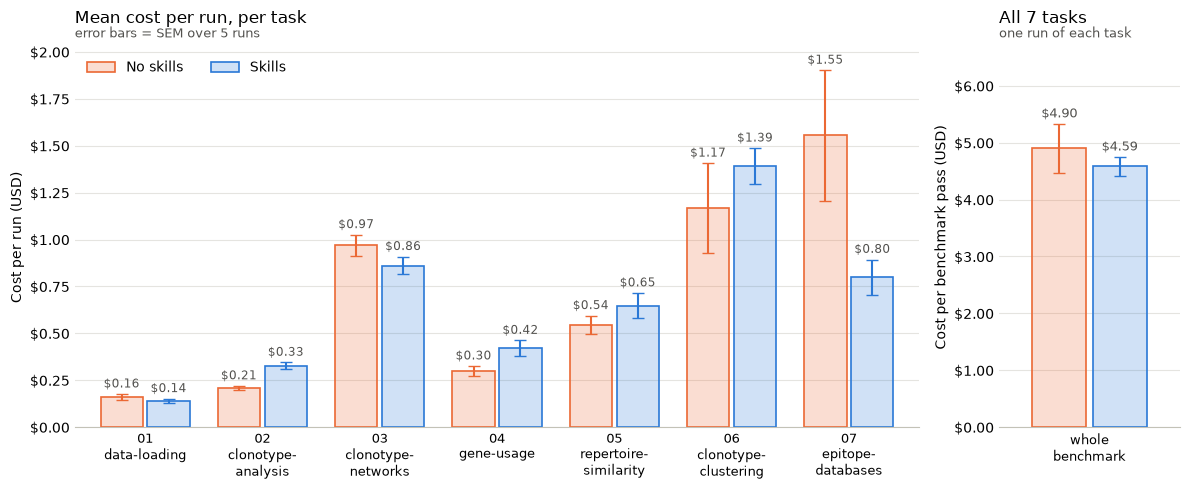

In [11]:
def style_cost_axis(ax):
  ax.grid(axis="y", color="#e5e4e0", linewidth=0.8)
  ax.set_axisbelow(True)
  for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
  ax.spines["bottom"].set_color("#c3c2b7")
  ax.tick_params(length=0)
  ax.yaxis.set_major_formatter(lambda v, _: f"\\${v:,.2f}")  # \$ is not mathtext

def plot_cost(runs: pd.DataFrame, axs=None):
  tasks = sorted(runs["task"].unique())
  if axs is None:
    _, axs = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [7, 1.5]})
  task_ax, benchmark_ax = axs
  pass_costs, pass_errors = [], []

  for skills, (color, _) in SERIES.items():
    arm = runs[runs["skills"] == skills]
    stats = arm.groupby("task")["cost_usd"].agg(["mean", "sem"]).reindex(tasks)
    xs = [i + (0.2 if skills else -0.2) for i in range(len(tasks))]
    task_ax.bar(
      xs, stats["mean"], yerr=stats["sem"], width=0.36, color=color + "38",
      edgecolor=color, linewidth=1.2, ecolor=color, capsize=4, zorder=2,
    )
    for x, mean, error in zip(xs, stats["mean"], stats["sem"]):
      task_ax.text(
        x, mean + error + 0.02, f"\\${mean:.2f}",
        ha="center", va="bottom", fontsize=8.5, color="#52514e",
      )

    # a benchmark pass is one run of each task, so sum the per-task means;
    # tasks are independent runs, so their standard errors add in quadrature
    pass_cost = stats["mean"].sum()
    pass_error = np.sqrt((stats["sem"] ** 2).sum())
    pass_costs.append(pass_cost)
    pass_errors.append(pass_error)
    x = 0.2 if skills else -0.2
    benchmark_ax.bar(
      x, pass_cost, yerr=pass_error, width=0.36, color=color + "38",
      edgecolor=color, linewidth=1.2, ecolor=color, capsize=4, zorder=2,
    )
    benchmark_ax.text(
      x, pass_cost + pass_error + 0.06, f"\\${pass_cost:.2f}",
      ha="center", va="bottom", fontsize=9, color="#52514e",
    )

  task_ax.set_xticks(range(len(tasks)))
  task_ax.set_xticklabels(
    [f'{t.split("-")[0]}\n' + textwrap.fill(t.split("-", 1)[1], 12) for t in tasks], fontsize=9
  )
  task_ax.set_xlim(-0.6, len(tasks) - 0.4)
  task_ax.set_ylim(0, runs.groupby(["task", "skills"])["cost_usd"].mean().max() * 1.3)
  task_ax.set_ylabel("Cost per run (USD)")
  task_ax.set_title("Mean cost per run, per task", loc="left", pad=18)
  task_ax.text(
    0, 1.02, f"error bars = SEM over {RUNS_PER_BATCH} runs", transform=task_ax.transAxes,
    ha="left", va="bottom", fontsize=9, color="#52514e",
  )
  task_ax.legend(
    handles=[
      Patch(facecolor=color + "38", edgecolor=color, linewidth=1.2, label=label)
      for color, label in SERIES.values()
    ],
    frameon=False, loc="upper left", ncol=2,
  )
  style_cost_axis(task_ax)

  benchmark_ax.set_xticks([0])
  benchmark_ax.set_xticklabels(["whole\nbenchmark"], fontsize=9)
  benchmark_ax.set_xlim(-0.6, 0.6)
  benchmark_ax.set_ylim(0, max(c + e for c, e in zip(pass_costs, pass_errors)) * 1.25)
  benchmark_ax.set_ylabel("Cost per benchmark pass (USD)")
  benchmark_ax.set_title(f"All {len(tasks)} tasks", loc="left", pad=18)
  benchmark_ax.text(
    0, 1.02, "one run of each task", transform=benchmark_ax.transAxes,
    ha="left", va="bottom", fontsize=9, color="#52514e",
  )
  style_cost_axis(benchmark_ax)
  return axs

fig, axs = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [7, 1.5]})
plot_cost(priced, axs=axs)
fig.tight_layout()
plt.show()
